##### 📊 End-to-End Data Pipeline for Recommendation System  

**Course:** Data Management for Machine Learning  
**Assignment:** I  
**Type:** Group Assignment  

**Team Members:**  
- Member 1  : SUJATHA K (2025AE05026)
- Member 2  
- Member 3  
- Member 4  

# End-to-End Data Management Pipeline for Recommendation System  

## Introduction

This notebook is part of a group assignment focused on building an end-to-end data pipeline for a recommendation system.

Recommendation systems are widely used in e-commerce platforms to:
- Improve user experience  
- Increase engagement  
- Boost sales through personalized suggestions  

In this project, we simulate a real-world scenario where an e-commerce platform (RecoMart) collects data from multiple sources such as:
- User clickstream logs  
- Product metadata  

## Scope

This notebook focuses on:

- **Task 5:** Data Preparation  
- **Task 6:** Feature Engineering and Transformation  
*** to be filled when subsequent tasks are implemented ***

This deliverable will:
- Clean and preprocess raw data  
- Merge datasets  
- Generate meaningful features for recommendation systems  

These steps ensure that the data is structured, reliable, and ready for machine learning models.

## Data Preparation

In this step, we prepare the raw data to make it suitable for further processing and feature engineering.

### Objectives:
- Handle missing values  
- Remove duplicate records  
- Ensure consistent data formats  
- Merge multiple data sources  
- Prepare a clean dataset for analysis  

### Data Used:
- **Clickstream Data:** Captures user interactions (views, clicks, etc.)  
- **Product Data:** Contains product details like category, brand, and price  

### Key Steps:
1. Data Loading  
2. Data Cleaning  
3. Data Merging  
4. Encoding and Normalization  

The output of this step is a **clean and structured dataset** ready for feature engineering.

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

# Project root = current working folder
project_root = Path.cwd()

# File paths relative to current folder
clickstream_path = project_root / "data" / "raw" / "clickstream" / "events" / "ingest_date=2026-02-16" / "ingest_hour=13" / "clickstream_2026-02-15.csv"
products_path = project_root / "sample_input" / "products_mock.json"

# Load data
clickstream = pd.read_csv(clickstream_path)
products = pd.read_json(products_path)

# Normalize product JSON
products_df = pd.json_normalize(products["items"])

print("Current working folder:", project_root)
print("Clickstream path:", clickstream_path)
print("Products path:", products_path)

print("\nClickstream Data:")
display(clickstream.head())

print("\nProduct Data:")
display(products_df.head())


Current working folder: c:\Users\Ashikaag\Downloads\RecoMart_Task2_Ingestion_Scripts_and_Logs
Clickstream path: c:\Users\Ashikaag\Downloads\RecoMart_Task2_Ingestion_Scripts_and_Logs\data\raw\clickstream\events\ingest_date=2026-02-16\ingest_hour=13\clickstream_2026-02-15.csv
Products path: c:\Users\Ashikaag\Downloads\RecoMart_Task2_Ingestion_Scripts_and_Logs\sample_input\products_mock.json

Clickstream Data:


,user_id,session_id,event_type,item_id,event_timestamp,device_type,platform
0,u1,s1,view,p101,2026-02-15T10:00:00Z,mobile,android
1,u1,s1,add_to_cart,p101,2026-02-15T10:01:00Z,mobile,android
2,u2,s2,view,p202,2026-02-15T11:00:00Z,web,chrome



Product Data:


,item_id,title,category,brand,price,availability_status
0,p101,Wireless Mouse,Electronics,Logi,799,in_stock
1,p202,Yoga Mat,Sports,Flex,499,in_stock


### Step 2: Data Inspection (Before Cleaning)

Before performing any cleaning, we inspect the dataset to understand:

- Missing values  
- Duplicate records  
- Data types  
- Overall structure  

This helps identify data quality issues that need to be addressed.

In [10]:
# -------------------------------
# Basic Info
# -------------------------------
print("Clickstream Info:")
clickstream.info()

print("\nProduct Info:")
products_df.info()

# -------------------------------
# Missing Values
# -------------------------------
print("\nMissing Values in Clickstream:")
print(clickstream.isnull().sum())

print("\nMissing Values in Products:")
print(products_df.isnull().sum())

# -------------------------------
# Duplicate Records
# -------------------------------
print("\nDuplicate Rows in Clickstream:", clickstream.duplicated().sum())
print("Duplicate Rows in Products:", products_df.duplicated().sum())

# -------------------------------
# Preview Data
# -------------------------------
print("\nSample Clickstream Data:")
display(clickstream.head())

print("\nSample Product Data:")
display(products_df.head())

Clickstream Info:
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   user_id          3 non-null      str  
 1   session_id       3 non-null      str  
 2   event_type       3 non-null      str  
 3   item_id          3 non-null      str  
 4   event_timestamp  3 non-null      str  
 5   device_type      3 non-null      str  
 6   platform         3 non-null      str  
dtypes: str(7)
memory usage: 300.0 bytes

Product Info:
<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   item_id              2 non-null      str  
 1   title                2 non-null      str  
 2   category             2 non-null      str  
 3   brand                2 non-null      str  
 4   price                2 non-null      int64
 5   availabilit

,user_id,session_id,event_type,item_id,event_timestamp,device_type,platform
0,u1,s1,view,p101,2026-02-15T10:00:00Z,mobile,android
1,u1,s1,add_to_cart,p101,2026-02-15T10:01:00Z,mobile,android
2,u2,s2,view,p202,2026-02-15T11:00:00Z,web,chrome



Sample Product Data:


,item_id,title,category,brand,price,availability_status
0,p101,Wireless Mouse,Electronics,Logi,799,in_stock
1,p202,Yoga Mat,Sports,Flex,499,in_stock


### Observations from Data Inspection

After analyzing the raw datasets, the following observations were made:

#### Data Structure:
- Clickstream dataset contains **7 columns** including user interactions and timestamps  
- Product dataset contains **6 columns** including item details and pricing  

#### Data Types:
- Most columns are of type **string (object)**  
- `price` is correctly stored as a **numeric (int64)**  
- ⚠️
-
-   `event_timestamp` is currently stored as a **string**, which needs conversion to datetime  

#### Missing Values:
- No missing values found in either dataset  

#### Duplicates:
- No duplicate records present  

#### Key Insight:
- Although the dataset is clean, **timestamp conversion is required** for time-based analysis  

---

### Identified Improvement:
- Convert `event_timestamp` from string → datetime format  

### Step 3: Data Cleaning

In this step, we clean the datasets to ensure data quality.

### Checks Performed: 
(This is a routine preprocessing. Even though the above cell implies the handliing of missing and duplicate values are not required, we still perform this as kind of routine)
- Remove duplicate records  
- Handle missing values  
- Ensure consistency in key columns
- Convert time format

Clean data is essential for generating reliable features and accurate models.

In [11]:
# -------------------------------
# Remove duplicates
# -------------------------------
clickstream = clickstream.drop_duplicates()
products_df = products_df.drop_duplicates()

# -------------------------------
# Handle missing values
# -------------------------------
clickstream = clickstream.fillna({
    'user_id': 'unknown',
    'product_id': 'unknown'
})

# Fill missing price with mean
products_df['price'] = products_df['price'].fillna(products_df['price'].mean())

# -------------------------------
# Convert timestamp to datetime
# -------------------------------
clickstream['event_timestamp'] = pd.to_datetime(clickstream['event_timestamp'])

# Verify conversion
print(clickstream.dtypes)

print("\nSample timestamps after conversion:")
display(clickstream[['event_timestamp']].head())

# -------------------------------
# Basic sanity check
# -------------------------------
print("Missing values after cleaning:\n")
print(clickstream.isnull().sum())
print(products_df.isnull().sum())

print("\nData cleaning completed")

user_id                            str
session_id                         str
event_type                         str
item_id                            str
event_timestamp    datetime64[us, UTC]
device_type                        str
platform                           str
dtype: object

Sample timestamps after conversion:


,event_timestamp
0,2026-02-15 10:00:00+00:00
1,2026-02-15 10:01:00+00:00
2,2026-02-15 11:00:00+00:00


Missing values after cleaning:

user_id            0
session_id         0
event_type         0
item_id            0
event_timestamp    0
device_type        0
platform           0
dtype: int64
item_id                0
title                  0
category               0
brand                  0
price                  0
availability_status    0
dtype: int64

Data cleaning completed


### Step 4: Data Merging

In this step, we combine the clickstream data with product metadata.

### Objective:
- Enrich user interaction data with product details  
- Enable feature engineering using both behavioral and product attributes  

### Join Key:
- `item_id` is used as the common key between both datasets  

### Outcome:
A unified dataset containing:
- User interactions  
- Product attributes (category, price, brand)  

In [12]:
# -------------------------------
# Merge clickstream with product data
# -------------------------------
df = clickstream.merge(
    products_df,
    on='item_id',
    how='left'
)

# -------------------------------
# Check merged data
# -------------------------------
print("Merged Dataset Info:\n")
df.info()

print("\nSample Merged Data:")
display(df.head())

Merged Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   user_id              3 non-null      str                
 1   session_id           3 non-null      str                
 2   event_type           3 non-null      str                
 3   item_id              3 non-null      str                
 4   event_timestamp      3 non-null      datetime64[us, UTC]
 5   device_type          3 non-null      str                
 6   platform             3 non-null      str                
 7   title                3 non-null      str                
 8   category             3 non-null      str                
 9   brand                3 non-null      str                
 10  price                3 non-null      int64              
 11  availability_status  3 non-null      str                
dtypes: datetime64[u

,user_id,session_id,event_type,item_id,event_timestamp,device_type,platform,title,category,brand,price,availability_status
0,u1,s1,view,p101,2026-02-15 10:00:00+00:00,mobile,android,Wireless Mouse,Electronics,Logi,799,in_stock
1,u1,s1,add_to_cart,p101,2026-02-15 10:01:00+00:00,mobile,android,Wireless Mouse,Electronics,Logi,799,in_stock
2,u2,s2,view,p202,2026-02-15 11:00:00+00:00,web,chrome,Yoga Mat,Sports,Flex,499,in_stock


### Post-Merge Validation

After merging, we verify:

- No unintended data loss  
- Presence of product attributes  
- Null values introduced due to unmatched keys  

This ensures the integrity of the merged dataset.

In [13]:
# Check missing values after merge
print("Missing values after merge:\n")
print(df.isnull().sum())

# Check if any product info is missing
missing_products = df[df['title'].isnull()]
print("\nRows with missing product info:")
display(missing_products)

Missing values after merge:

user_id                0
session_id             0
event_type             0
item_id                0
event_timestamp        0
device_type            0
platform               0
title                  0
category               0
brand                  0
price                  0
availability_status    0
dtype: int64

Rows with missing product info:


,user_id,session_id,event_type,item_id,event_timestamp,device_type,platform,title,category,brand,price,availability_status


### Post-Merge Observations

After merging the clickstream and product datasets, the following observations were made:

#### Missing Values:
- No missing values were found in any column after the merge  
- This indicates that all `item_id` values in the clickstream dataset have matching entries in the product dataset  

#### Data Integrity:
- The merge was successful without any data loss  
- All user interaction records are retained  

#### Product Enrichment:
- Each interaction is now enriched with:
  - Product title  
  - Category  
  - Brand  
  - Price  
  - Availability status  

#### Key Insight:
- Since no null values were introduced, the datasets are **fully aligned and consistent**

### Conclusion:
The merged dataset is clean, complete, and ready for further preprocessing steps such as encoding and normalization.

### Step 5: Encoding and Normalization

In this step, we transform the data into a format suitable for machine learning models.

### Objectives:
- Convert categorical variables into numerical form  
- Normalize numerical features for consistency  

### Transformations Applied:

#### 1. Encoding Categorical Variables
- Convert `category`, `brand`, and `platform` into numeric representations  

#### 2. Normalization
- Scale `price` to ensure consistent range across features  

#### Purpose
- Machine learning models require numerical input  
- Normalization prevents features with large values from dominating  

In [14]:
# -------------------------------
# Encoding categorical variables
# -------------------------------
df['category_encoded'] = df['category'].astype('category').cat.codes
df['brand_encoded'] = df['brand'].astype('category').cat.codes
df['platform_encoded'] = df['platform'].astype('category').cat.codes

# -------------------------------
# Normalizing numerical feature (price)
# -------------------------------
df['price_normalized'] = (df['price'] - df['price'].mean()) / df['price'].std()

# -------------------------------
# Verify transformation
# -------------------------------
print("Encoded & Normalized Data:\n")
display(df[['category', 'category_encoded',
            'brand', 'brand_encoded',
            'platform', 'platform_encoded',
            'price', 'price_normalized']].head())

Encoded & Normalized Data:



,category,category_encoded,brand,brand_encoded,platform,platform_encoded,price,price_normalized
0,Electronics,0,Logi,1,android,0,799,0.577350
1,Electronics,0,Logi,1,android,0,799,0.577350
2,Sports,1,Flex,0,chrome,1,499,-1.154701


Label encoding is used for simplicity. In real-world scenarios, one-hot encoding or embeddings may be preferred.

## Exploratory Data Analysis (EDA)

Here,  the prepared dataset is analysed to understand:

- User interaction patterns  
- Product popularity  
- Distribution of key features  

EDA helps in validating assumptions and identifying trends in the data.

### User Interaction Distribution

We analyze how frequently users interact with the platform.

Matplotlib is building the font cache; this may take a moment.


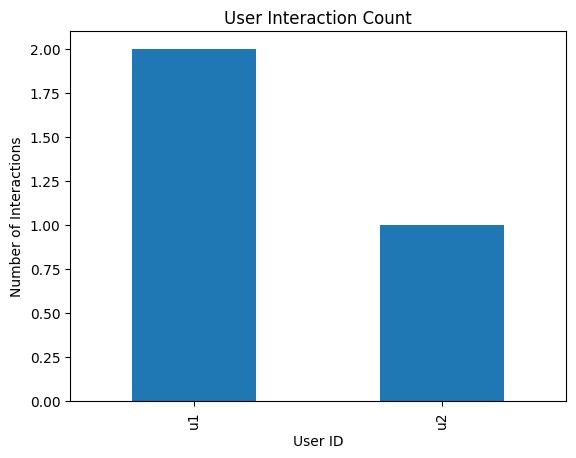

In [16]:
import matplotlib.pyplot as plt

# Count interactions per user
user_counts = df['user_id'].value_counts()

plt.figure()
user_counts.plot(kind='bar')
plt.title("User Interaction Count")
plt.xlabel("User ID")
plt.ylabel("Number of Interactions")
plt.show()

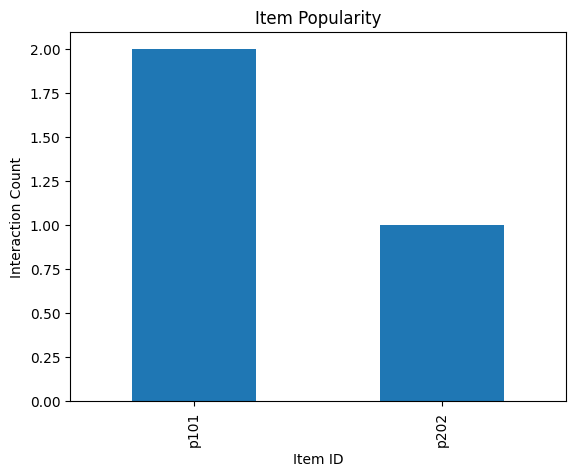

In [17]:
# Item Popularity
item_counts = df['item_id'].value_counts()

plt.figure()
item_counts.plot(kind='bar')
plt.title("Item Popularity")
plt.xlabel("Item ID")
plt.ylabel("Interaction Count")
plt.show()

### Insight: Item Popularity

The bar chart represents the number of interactions for each item.

#### Observations:
- Item **p101** has higher interaction count  
- Item **p202** has relatively fewer interactions  

#### Interpretation:
- Items with more interactions are considered **more popular**  
- Popular items indicate higher user interest or demand  

#### Impact on Recommendation System:
- Popular items can be recommended to:
  - New users (cold-start problem)  
  - Users with limited interaction history  
- Helps improve engagement by suggesting trending products  

Item interaction frequency is a key signal for identifying **popular products**, 
which is useful in building recommendation strategies.

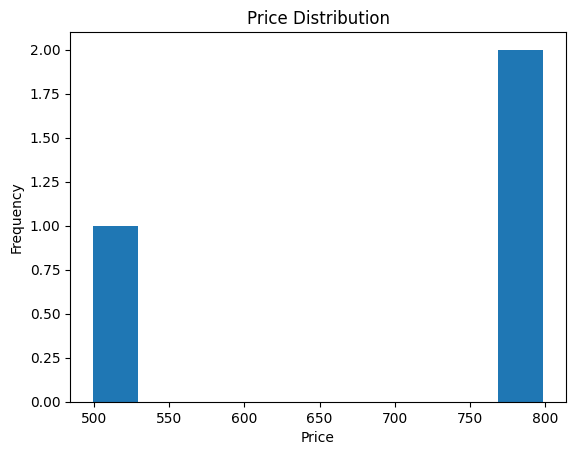

In [18]:
# Price Distribution
plt.figure()
df['price'].plot(kind='hist', bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### Insight: Price Distribution

The histogram shows the distribution of product prices in the dataset.

#### Observations:
- The dataset contains products with prices around two distinct values  
- Prices are spread across a limited range (e.g., low-cost vs relatively higher-cost items)  

#### Interpretation:
- The variation in price indicates different product categories or segments  
- Even in a small dataset, price differences help understand user preferences  

#### Impact on Recommendation System:
- Price can be used to:
  - Identify **budget-conscious users**  
  - Recommend products within a user's preferred price range  
- Helps in creating **personalized recommendations based on spending behavior**  


Price distribution is an important feature that captures **economic behavior of users**, 
which enhances recommendation quality when combined with interaction data.

### Insight: User Interaction Distribution

The bar chart shows the number of interactions per user.

#### Observations:
- User **u1** has higher interaction count compared to other users  
- User **u2** has fewer interactions  

#### Interpretation:
- Some users are more **active**, while others are **less engaged**  
- This indicates variability in user behavior  

#### Impact on Recommendation System:
- Highly active users provide more data → better personalization  
- Less active users may require fallback strategies (e.g., popular items)

### Conclusion:
User interaction data can be used to distinguish between:
- **Active users** (high engagement)
- **Cold users** (low interaction)

EDA is not part of the pipeline execution, but it is essential during the development phase to understand data characteristics and design meaningful features

## Feature Engineering

Based on insights derived from EDA, we create behavior-driven features for recommendation modeling.

### Observations from EDA:
- User **u1** has higher interaction frequency compared to user **u2**  
- Interaction data shows variation in user engagement levels  
- Some products appear more frequently, indicating higher popularity  


###  Feature Design Based on Observations:

####  User Activity Count
- Since users show different interaction frequencies (e.g., u1 > u2),  
  we created **activity_count** to capture user engagement levels  

#### Item Popularity
- As certain items appear more frequently in interactions,  
  we created **popularity** to represent item demand  

####  Average Price per User
- Based on product price variation,  
  we created **avg_price** to capture user spending behavior  


###  Why This Approach is Effective:
- Features are derived from **actual observed patterns**, not assumptions  
- Helps distinguish between:
  - Active vs less active users  
  - Popular vs less popular items  
- Improves the quality of recommendations  

###  Conclusion:
The EDA insights directly guided the feature engineering process, ensuring that the generated features are meaningful, relevant, and aligned with user behavior patterns.

In [19]:
# -------------------------------
# Feature Engineering
# -------------------------------

# 1 Recency feature
df['recency'] = (df['event_timestamp'].max() - df['event_timestamp']).dt.total_seconds()

# 2. User Activity Count
# Number of interactions per user
user_activity = df.groupby('user_id').size().reset_index(name='activity_count')


# 3. Average Price per User
# Captures spending behavior
avg_price_user = df.groupby('user_id')['price'].mean().reset_index(name='avg_price')


# 4. Item Popularity
# Number of interactions per item
item_popularity = df.groupby('item_id').size().reset_index(name='popularity')


# -------------------------------
# Merge all features into dataset
# -------------------------------
features = df.merge(user_activity, on='user_id', how='left')
features = features.merge(avg_price_user, on='user_id', how='left')
features = features.merge(item_popularity, on='item_id', how='left')


# -------------------------------
# Preview final feature dataset
# -------------------------------
print("Final Feature Dataset:\n")
display(features.head())

Final Feature Dataset:



,user_id,session_id,event_type,item_id,event_timestamp,device_type,platform,title,category,brand,price,availability_status,category_encoded,brand_encoded,platform_encoded,price_normalized,recency,activity_count,avg_price,popularity
0,u1,s1,view,p101,2026-02-15 10:00:00+00:00,mobile,android,Wireless Mouse,Electronics,Logi,799,in_stock,0,1,0,0.577350,3600.0,2,799.0,2
1,u1,s1,add_to_cart,p101,2026-02-15 10:01:00+00:00,mobile,android,Wireless Mouse,Electronics,Logi,799,in_stock,0,1,0,0.577350,3540.0,2,799.0,2
2,u2,s2,view,p202,2026-02-15 11:00:00+00:00,web,chrome,Yoga Mat,Sports,Flex,499,in_stock,1,0,1,-1.154701,0.0,1,499.0,1


In [20]:
# Select only relevant columns for modeling
final_features = features[[
    'user_id',
    'item_id',
    'activity_count',
    'avg_price',
    'popularity',
    'recency'
]]

display(final_features.head())

,user_id,item_id,activity_count,avg_price,popularity,recency
0,u1,p101,2,799.0,2,3600.0
1,u1,p101,2,799.0,2,3540.0
2,u2,p202,1,499.0,1,0.0


### Feature Summary

- **activity_count** → measures user engagement  
- **avg_price** → captures user spending behavior  
- **popularity** → indicates item deman
- **recency**
 Measures how recent each user interaction is  
Calculated as the time difference between the latest interaction and current interaction  
Lower values indicate more recent activity  

📌 Importance:
Recency helps capture **temporal user behavior**, which is crucial in recommendation systems where recent actions are often more relevant than older ones.

These features are derived from interaction data and are useful for recommendation systems.

These features are simple but powerful behavioral signals commonly used in recommendation systems, especially for collaborative filtering.

## Feature Store

In this task, we build a **Feature Store** by transforming raw ingested data into structured, model-ready features.

The goal is to create reusable and consistent features from:
- Clickstream data (user interactions)
- Product data (catalog information)

---

### 🎯 Objective
- Combine and transform raw datasets  
- Generate meaningful features for downstream ML models  
- Ensure consistency and reusability of features  

---

### ⚙️ Feature Engineering Includes
- User-level aggregations (e.g., clicks, sessions)  
- Product-level attributes (e.g., category, price signals)  
- Derived features (e.g., interaction counts, frequency)  

---

### 📂 Input Data
- `data/raw/clickstream/`
- `data/raw/catalog/`

---

### 📂 Output
- Feature datasets stored in `data/feature_store/` (or equivalent)

---

### 🧠 Why Feature Store?
A Feature Store helps:
- Avoid duplicate feature engineering work  
- Maintain consistency between training and inference  
- Improve model performance with reliable inputs  

---

In [25]:
# -------------------------------
# Task 7: Simple Custom Feature Store
# -------------------------------

import os
import json
import pandas as pd
from datetime import datetime

# If final_features does not exist, build it from df
if 'final_features' not in globals():
    if 'df' not in globals():
        raise ValueError("`df` is not available. Please run the data loading, cleaning, merging, and Task 6 cells first.")

    # Rebuild Task 6 features
    df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])
    df['recency'] = (df['event_timestamp'].max() - df['event_timestamp']).dt.total_seconds()

    user_activity = df.groupby('user_id').size().reset_index(name='activity_count')
    avg_price_user = df.groupby('user_id')['price'].mean().reset_index(name='avg_price')
    item_popularity = df.groupby('item_id').size().reset_index(name='popularity')

    features = df.merge(user_activity, on='user_id', how='left')
    features = features.merge(avg_price_user, on='user_id', how='left')
    features = features.merge(item_popularity, on='item_id', how='left')

    final_features = features[[
        'user_id',
        'item_id',
        'activity_count',
        'avg_price',
        'popularity',
        'recency'
    ]].copy()

# Base folder for feature store
FEATURE_STORE_ROOT = "feature_store"
os.makedirs(FEATURE_STORE_ROOT, exist_ok=True)

# Version using timestamp
feature_version = datetime.now().strftime("%Y%m%d_%H%M%S")
version_path = os.path.join(FEATURE_STORE_ROOT, feature_version)
os.makedirs(version_path, exist_ok=True)

# 1. Store feature data
feature_data_path = os.path.join(version_path, "final_features.csv")
final_features.to_csv(feature_data_path, index=False)

# 2. Create feature metadata
feature_metadata = {
    "feature_store_name": "recomart_feature_store",
    "version": feature_version,
    "created_at": datetime.now().isoformat(),
    "entity_keys": ["user_id", "item_id"],
    "source_dataset": "final_features",
    "features": [
        {
            "name": "activity_count",
            "dtype": "int",
            "source": "clickstream",
            "transformation": "count of interactions grouped by user_id"
        },
        {
            "name": "avg_price",
            "dtype": "float",
            "source": "products + clickstream",
            "transformation": "average price grouped by user_id"
        },
        {
            "name": "popularity",
            "dtype": "int",
            "source": "clickstream",
            "transformation": "count of interactions grouped by item_id"
        },
        {
            "name": "recency",
            "dtype": "float",
            "source": "clickstream",
            "transformation": "time difference in seconds from latest event_timestamp"
        }
    ]
}

metadata_path = os.path.join(version_path, "feature_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(feature_metadata, f, indent=4)

print("Feature store version created:", feature_version)
print("Feature data saved at:", feature_data_path)
print("Metadata saved at:", metadata_path)

# 3. Retrieval functions
def load_feature_metadata(version, root=FEATURE_STORE_ROOT):
    path = os.path.join(root, version, "feature_metadata.json")
    with open(path, "r") as f:
        return json.load(f)

def load_feature_data(version, root=FEATURE_STORE_ROOT):
    path = os.path.join(root, version, "final_features.csv")
    return pd.read_csv(path)

def get_training_features(version, root=FEATURE_STORE_ROOT):
    return load_feature_data(version, root)

def get_inference_features(user_id=None, item_id=None, version=None, root=FEATURE_STORE_ROOT):
    df_fs = load_feature_data(version, root)

    if user_id is not None:
        df_fs = df_fs[df_fs["user_id"] == user_id]
    if item_id is not None:
        df_fs = df_fs[df_fs["item_id"] == item_id]

    return df_fs

# 4. Demonstration
print("\nFeature Metadata:")
display(pd.DataFrame(load_feature_metadata(feature_version)["features"]))

print("\nTraining Feature Retrieval:")
display(get_training_features(feature_version).head())

print("\nInference Feature Retrieval:")
sample_user = final_features.iloc[0]["user_id"]
sample_item = final_features.iloc[0]["item_id"]
display(get_inference_features(user_id=sample_user, item_id=sample_item, version=feature_version))


Feature store version created: 20260428_160922
Feature data saved at: feature_store\20260428_160922\final_features.csv
Metadata saved at: feature_store\20260428_160922\feature_metadata.json

Feature Metadata:


,name,dtype,source,transformation
0,activity_count,int,clickstream,count of interactions grouped by user_id
1,avg_price,float,products + clickstream,average price grouped by user_id
2,popularity,int,clickstream,count of interactions grouped by item_id
3,recency,float,clickstream,time difference in seconds from latest event_t...



Training Feature Retrieval:


,user_id,item_id,activity_count,avg_price,popularity,recency
0,u1,p101,2,799.0,2,3600.0
1,u1,p101,2,799.0,2,3540.0
2,u2,p202,1,499.0,1,0.0



Inference Feature Retrieval:


,user_id,item_id,activity_count,avg_price,popularity,recency
0,u1,p101,2,799.0,2,3600.0
1,u1,p101,2,799.0,2,3540.0
